# BALIK TÜRLERİNİN SINIFLANDIRILMASI

Bu proje, çeşitli balık türlerinin görüntülerini kullanarak otomatik sınıflandırma yapan gelişmiş bir derin öğrenme modeli geliştirmeyi amaçlar.Transfer learning, data augmentation ve model optimization teknikleri kullanılarak yüksek doğruluk oranı hedeflenmektedir.

In [1]:
# pip install -q protobuf==3.20.3

In [21]:
import os
import glob as gb
import numpy as np 
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.applications import MobileNetV2,VGG16
from tensorflow.keras.layers import Conv2D,Flatten,Dropout,BatchNormalization,Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping,ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,array_to_img,img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [22]:
# Dosya yollarını ekle
fish_path=r'/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset'
all_path=[] # To include the full path of each image
for img_path in os.listdir(fish_path): 
    if img_path in ['Segmentation_example_script.m','README.txt','license.txt'] :
        continue
        
    all_data=gb.glob(pathname=fish_path+'/'+img_path+'/'+img_path+'/*.*')
    print(' found {} in {} '.format(len(all_data),img_path))
    all_path.extend(all_data)

 found 1000 in Hourse Mackerel 
 found 1000 in Black Sea Sprat 
 found 1000 in Sea Bass 
 found 1000 in Red Mullet 
 found 1000 in Trout 
 found 1000 in Striped Red Mullet 
 found 1000 in Shrimp 
 found 1000 in Gilt-Head Bream 
 found 1000 in Red Sea Bream 


In [24]:
# Balık df oluştur
images_df=pd.DataFrame({'Filepath':all_path})
images_df['Label']=images_df['Filepath'].apply(lambda x :x.split('/')[-2])
pd.options.display.max_colwidth = 200

#shuffling and reset index
images_df = images_df.sample(frac=1).reset_index(drop = True)

In [25]:
images_df.head(5)

,Filepath,Label
0,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Black Sea Sprat/Black Sea Sprat/00637.png,Black Sea Sprat
1,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Sea Bass/Sea Bass/00624.png,Sea Bass
2,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Shrimp/Shrimp/00654.png,Shrimp
3,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Red Sea Bream/Red Sea Bream/00921.png,Red Sea Bream
4,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00611.png,Striped Red Mullet


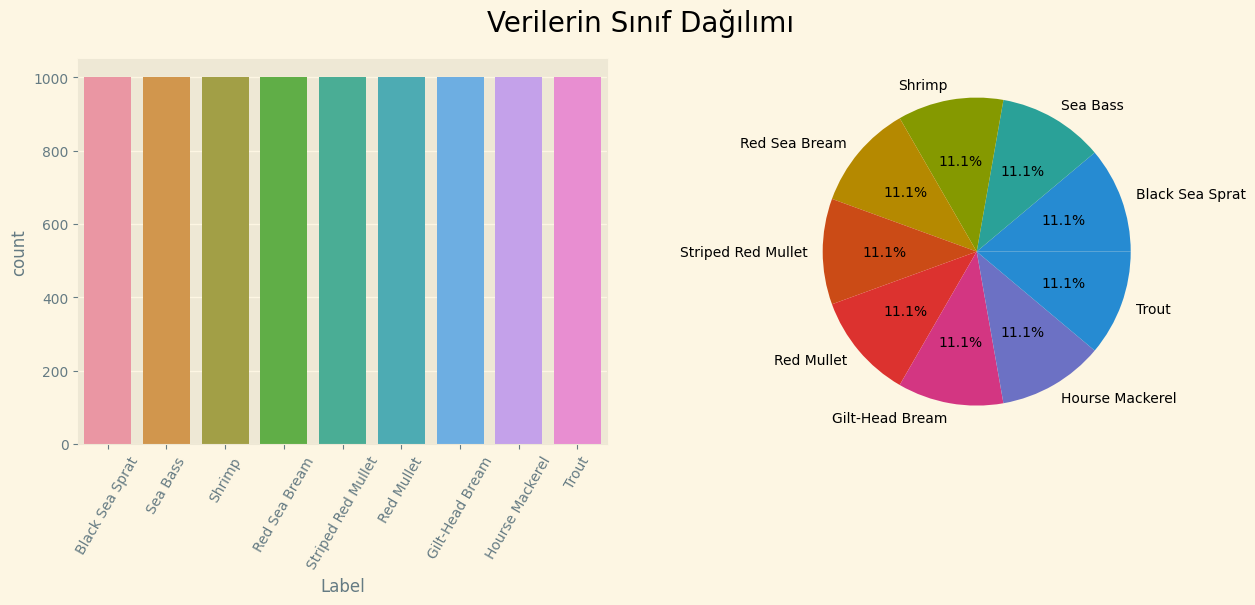

In [27]:
# Verilerin Sınıf Dağılımı
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(data=images_df,x='Label')
plt.xticks(rotation = 60)
plt.subplot(1,2,2)
plt.pie(x=images_df['Label'].value_counts().values,labels=images_df['Label'].value_counts().index,autopct='%1.1f%%')
plt.suptitle('Verilerin Sınıf Dağılımı',size=20)
plt.show()

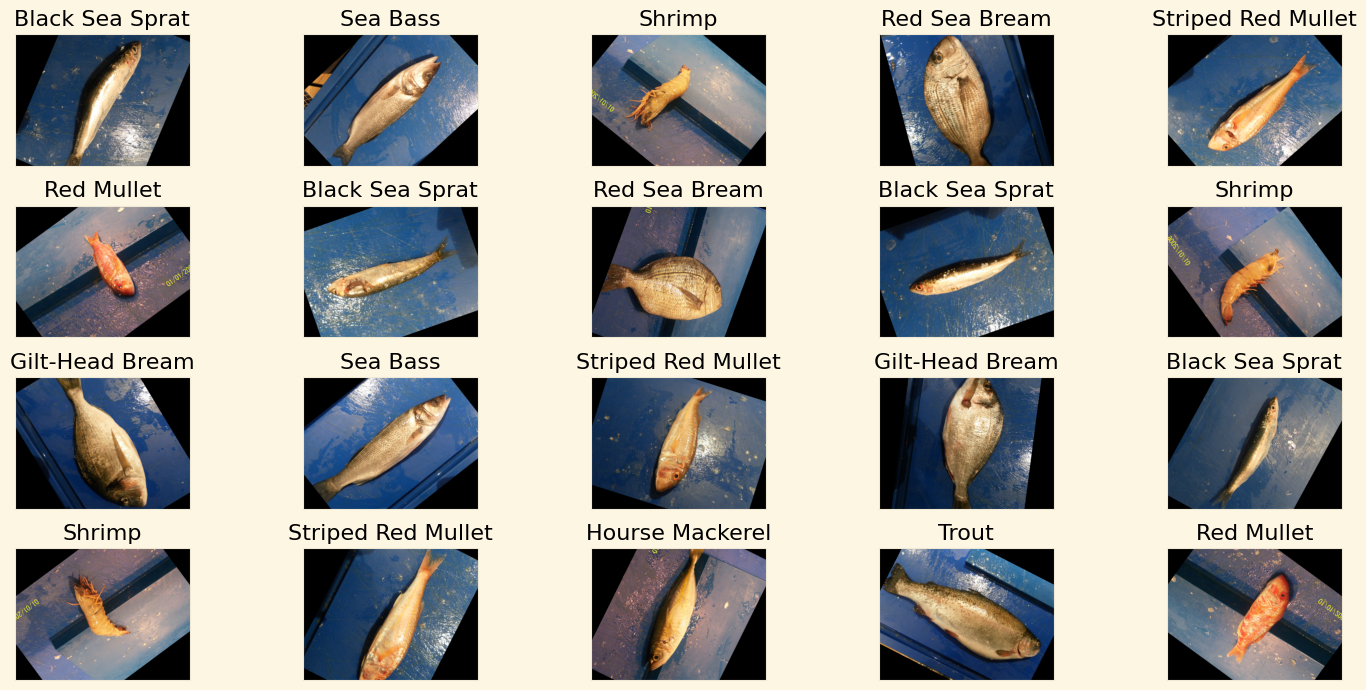

In [29]:
#  20 balık resmi gorelim
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(15, 7),subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(images_df.Filepath[i]))
    ax.set_title(images_df.Label[i])
plt.tight_layout()
plt.show()

In [30]:
# Verileri bölelim
training_df,testing_df=train_test_split(images_df,test_size=0.1,shuffle=True,random_state=1)

In [31]:
training_generator=ImageDataGenerator(tf.keras.applications.vgg16.preprocess_input,validation_split=0.2,)
testing_generator=ImageDataGenerator(tf.keras.applications.vgg16.preprocess_input)

In [32]:
training_images=training_generator.flow_from_dataframe(
    dataframe=training_df,
    x_col='Filepath',
    y_col='Label',
    class_mode='categorical',
    target_size=(224, 224),    
    color_mode='rgb',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'   
)


validation_images=training_generator.flow_from_dataframe(
    dataframe=training_df,
    x_col='Filepath',
    y_col='Label',
    class_mode='categorical',
    target_size=(224,224),
    color_mode='rgb',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)


testing_images=testing_generator.flow_from_dataframe(
    dataframe=testing_df,
    x_col='Filepath',
    y_col='Label',
    class_mode='categorical',
    target_size=(224,224),
    color_mode='rgb',
    batch_size=32,
    shuffle=False,
)

Found 6480 validated image filenames belonging to 9 classes.
Found 1620 validated image filenames belonging to 9 classes.
Found 900 validated image filenames belonging to 9 classes.


In [33]:
pretrained_model=VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
early_stopping=EarlyStopping(monitor='val_loss',patience=3,verbose=1,restore_best_weights=True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=2,verbose=0,factor=0.1)
model_check_point=ModelCheckpoint(monitor='val_accuracy',filepath='./bestmodel.h5',save_best_only=True,verbose=True)

In [35]:
inputs=pretrained_model.input
x=Dense(128,activation='relu')(pretrained_model.output)
x=Dense(128,activation='relu')(x)
x=Dropout(rate=0.3)(x)
x=BatchNormalization()(x)
x=Dense(64,activation='relu')(x)
outputs=Dense(9,activation='softmax')(x)
model=Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [36]:
history=model.fit(
    training_images,
    validation_data=validation_images,
    epochs=7,
    batch_size=32,
    callbacks=[early_stopping,reduce_lr,model_check_point]
)

Epoch 1/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.5675 - loss: 1.3145
Epoch 1: val_accuracy improved from -inf to 0.96914, saving model to ./bestmodel.h5


203/203 ━━━━━━━━━━━━━━━━━━━━ 189s 835ms/step - accuracy: 0.5685 - loss: 1.3116 - val_accuracy: 0.9691 - val_loss: 0.1218 - learning_rate: 0.0010
Epoch 2/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9591 - loss: 0.1325
Epoch 2: val_accuracy improved from 0.96914 to 0.98704, saving model to ./bestmodel.h5


203/203 ━━━━━━━━━━━━━━━━━━━━ 76s 373ms/step - accuracy: 0.9591 - loss: 0.1323 - val_accuracy: 0.9870 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 3/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9796 - loss: 0.0676
Epoch 3: val_accuracy improved from 0.98704 to 0.99506, saving model to ./bestmodel.h5


203/203 ━━━━━━━━━━━━━━━━━━━━ 76s 373ms/step - accuracy: 0.9796 - loss: 0.0676 - val_accuracy: 0.9951 - val_loss: 0.0256 - learning_rate: 0.0010
Epoch 4/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9892 - loss: 0.0402
Epoch 4: val_accuracy did not improve from 0.99506
203/203 ━━━━━━━━━━━━━━━━━━━━ 75s 371ms/step - accuracy: 0.9892 - loss: 0.0402 - val_accuracy: 0.9864 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 5/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9922 - loss: 0.0355
Epoch 5: val_accuracy did not improve from 0.99506
203/203 ━━━━━━━━━━━━━━━━━━━━ 77s 378ms/step - accuracy: 0.9922 - loss: 0.0355 - val_accuracy: 0.9938 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 6/7
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9940 - loss: 0.0223
Epoch 6: val_accuracy did not improve from 0.99506
203/203 ━━━━━━━━━━━━━━━━━━━━ 77s 376ms/step - accuracy: 0.9940 - loss: 0.0223 - val_accuracy: 0.9877 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 7/7


In [37]:
model.save("fish_model.h5")
model.save("fish_model.keras")

In [38]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 14,988,765 (57.18 MB)

 Trainable params: 91,273 (356.54 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

 Optimizer params: 182,548 (713.08 KB)

In [39]:
history_df=pd.DataFrame(history.history)

In [40]:
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.778704,0.723293,0.969136,0.121838,0.001
1,0.968518,0.106477,0.987037,0.043088,0.001
2,0.981636,0.066005,0.995062,0.025572,0.001
3,0.984722,0.051077,0.986420,0.055878,0.001
4,0.991512,0.029863,0.993827,0.015745,0.001
5,0.994136,0.021278,0.987654,0.045374,0.001
6,0.990895,0.030408,0.991358,0.026988,0.001


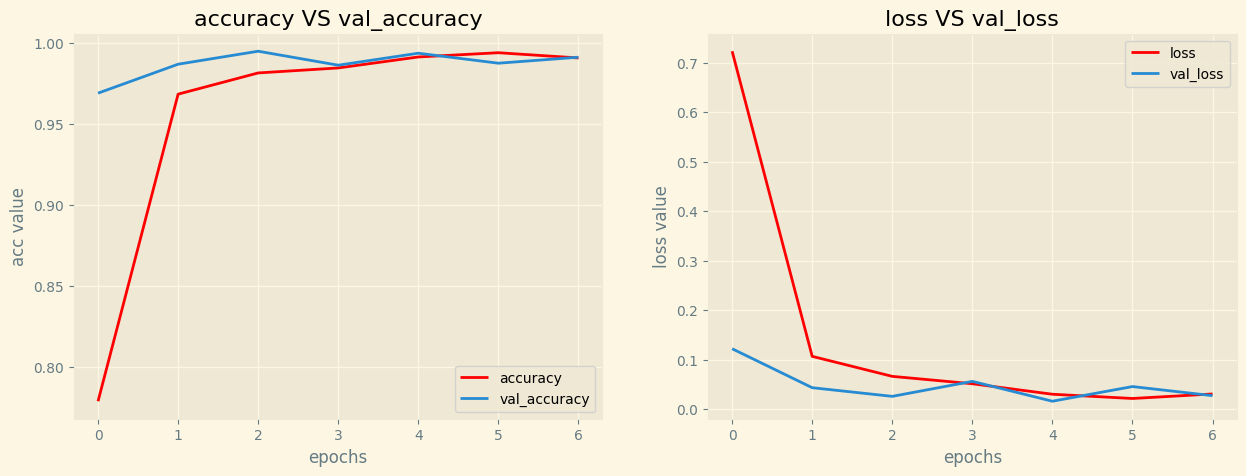

In [41]:
plt.figure(figsize=(15,5))

# plotting accuracy and val_accuracy
plt.subplot(1,2,1)
plt.plot(history_df['accuracy'],label='accuracy',c='red')
plt.plot(history_df['val_accuracy'],label='val_accuracy')
plt.xlabel('epochs')
plt.ylabel('acc value')
plt.title('accuracy VS val_accuracy')
plt.legend()
# plotting loss and val_loss
plt.subplot(1,2,2)
plt.plot(history_df['loss'],label='loss',c='red')
plt.plot(history_df['val_loss'],label='val_loss')
plt.title('loss VS val_loss')
plt.xlabel('epochs')
plt.ylabel('loss value')
plt.legend()

plt.show()

In [42]:
from keras.models import load_model

model=load_model('/kaggle/working/fish_model.h5')
Evaluation=model.evaluate(testing_images)
prediction=model.predict(testing_images)
prediction=np.argmax(prediction,axis=1)
training_images.class_indices
labels = (training_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
prediction = [labels[k] for k in prediction]
y_true=testing_df['Label'].values
print(classification_report(y_true,prediction))

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 714ms/step - accuracy: 0.9948 - loss: 0.0177
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 289ms/step
                    precision    recall  f1-score   support

   Black Sea Sprat       0.99      1.00      1.00       108
   Gilt-Head Bream       1.00      1.00      1.00       104
   Hourse Mackerel       1.00      1.00      1.00       109
        Red Mullet       1.00      0.94      0.97       103
     Red Sea Bream       1.00      1.00      1.00        78
          Sea Bass       1.00      0.99      1.00       105
            Shrimp       0.98      1.00      0.99       101
Striped Red Mullet       0.96      1.00      0.98       100
             Trout       1.00      1.00      1.00        92

          accuracy                           0.99       900
         macro avg       0.99      0.99      0.99       900
      weighted avg       0.99      0.99      0.99       900



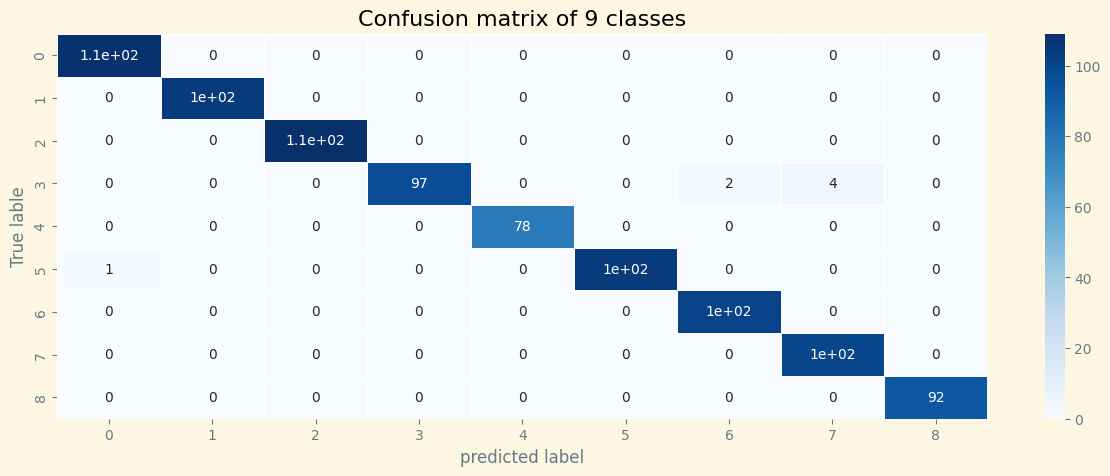

In [43]:
cm=confusion_matrix(y_true,prediction)
plt.figure(figsize=(15,5))
sns.heatmap(cm,annot=True,cmap='Blues',linewidths=0.5)
plt.xlabel('predicted label')
plt.ylabel('True lable')
plt.title('Confusion matrix of 9 classes')
plt.show()